# Import Required Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch → Core deep learning framework

nn → Neural network layers

optim → Optimizers

torchvision → MNIST dataset

DataLoader → Batch processing

matplotlib → Visualization

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Load MNIST Dataset

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               transform=transform,
                               download=True)

train_loader = DataLoader(train_dataset,
                          batch_size=128,
                          shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.06MB/s]


* Converts images to tensors.

* Downloads MNIST dataset.

* Uses batch size = 128.

* Shuffles data for better training.

Each image size = 28 × 28 = 784 pixels

# Define VAE Model

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64*7*7, latent_dim)
        self.fc_logvar = nn.Linear(64*7*7, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 64*7*7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(-1, 64, 7, 7)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

This VAE has 3 main parts:

1. Encoder

* Converts image → latent mean (μ)

* Converts image → log variance (log σ²)

2. Reparameterization Trick

* Instead of directly sampling randomly (which blocks learning), we separate randomness from the network calculations.
* This allows the model to learn properly using backpropagation while still sampling from a distribution.

3. Decoder

* Reconstructs image from latent vector z.

# Initialize Model and Optimizer

In [ ]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

* Creates VAE model

* Uses Adam optimizer

* Learning rate = 0.001

# Define Loss Function (Reconstruction + KL Divergence)

In [ ]:
def vae_loss(x_recon, x, mu, logvar):

    recon_loss = nn.functional.binary_cross_entropy(
        x_recon,
        x,
        reduction='sum'
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss, kl_loss

1. Reconstruction Loss

* Measures how close reconstructed image is to original.

* Uses Binary Cross Entropy because MNIST pixels ∈ [0,1].

2. KL Divergence Loss
* This forces the latent space to follow a normal distribution.
It ensures smooth, continuous, and meaningful latent representations.

# Training Loop

In [ ]:
epochs = 30

for epoch in range(epochs):

    model.train()

    total_recon = 0
    total_kl = 0

    for batch_idx, (data, _) in enumerate(train_loader):

        # Ensure data is 4D (batch, channels, height, width) for the Conv2d layers in the encoder
        data = data.to(device)

        optimizer.zero_grad()

        x_recon, mu, logvar = model(data)

        # Both x_recon and data are now 4D (batch, channels, height, width),
        # which is compatible for binary_cross_entropy when they have the same size.
        recon_loss, kl_loss = vae_loss(x_recon, data, mu, logvar)

        loss = recon_loss + kl_loss

        loss.backward()

        optimizer.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Reconstruction Loss: {total_recon/len(train_loader.dataset):.4f}")
    print(f"KL Divergence Loss: {total_kl/len(train_loader.dataset):.4f}")
    print("-"*50)

Epoch [1/30]
Reconstruction Loss: 152.4285
KL Divergence Loss: 23.1002
--------------------------------------------------
Epoch [2/30]
Reconstruction Loss: 94.4012
KL Divergence Loss: 26.8135
--------------------------------------------------
Epoch [3/30]
Reconstruction Loss: 88.2148
KL Divergence Loss: 26.8175
--------------------------------------------------
Epoch [4/30]
Reconstruction Loss: 84.7786
KL Divergence Loss: 26.6570
--------------------------------------------------
Epoch [5/30]
Reconstruction Loss: 82.6582
KL Divergence Loss: 26.5175
--------------------------------------------------
Epoch [6/30]
Reconstruction Loss: 81.2230
KL Divergence Loss: 26.4308
--------------------------------------------------
Epoch [7/30]
Reconstruction Loss: 80.2677
KL Divergence Loss: 26.3582
--------------------------------------------------
Epoch [8/30]
Reconstruction Loss: 79.5279
KL Divergence Loss: 26.3886
--------------------------------------------------
Epoch [9/30]
Reconstruction Los

Each epoch performs:

1. Forward Pass

* Input → Encoder → Latent Sampling → Decoder

2. Compute Loss

* Total Loss = Reconstruction Loss + KL Divergence

3. Backpropagation

* loss.backward()

* optimizer.step()

4. Print Both Losses

* You will see: Reconstruction loss and KL divergence loss

# Visualize Reconstruction

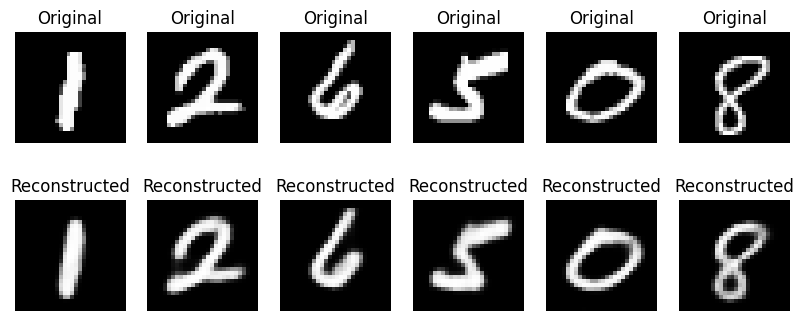

In [ ]:
model.eval()

with torch.no_grad():

    data, _ = next(iter(train_loader))

    data = data.to(device)

    recon, _, _ = model(data)

    data = data.cpu()
    recon = recon.cpu()

    fig, axes = plt.subplots(2,6, figsize=(10,4))

    for i in range(6):

        axes[0,i].imshow(data[i].squeeze(), cmap='gray')
        axes[0,i].set_title("Original")
        axes[0,i].axis("off")

        axes[1,i].imshow(recon[i].squeeze(), cmap='gray')
        axes[1,i].set_title("Reconstructed")
        axes[1,i].axis("off")

    plt.show()

* Takes one batch

* Reconstructs images

* Displays: Row 1 → Original images, Row 2 → Reconstructed images

You will see slightly blurry but meaningful digits — this is normal for VAE.